In [1]:
import os
os.chdir("..")

In [7]:
from src.config import *
from src.helpers import *
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Training

Each subject’s preprocessed data is saved in `PRODIR` under either the `chest` or `wrist` directories as `sXchest64.csv` or `sXwrist64.csv`. All files have already been resampled to a common sampling rate.  

The helper function `window_data_features()` is used to generate windowed feature matrices (`X_windows`) and corresponding labels (`y_windows`).  

I will train a Random Forest model on these windowed features.

For evaluation, I will use Leave-One-Subject-Out (LOSO) cross-validation. In each LOSO fold, normalization is performed using only the training subjects, and the resulting scaling parameters are applied to the held-out test subject. This prevents any information from the test subject leaking into the model. LOSO is chosen to evaluate model generalization across subjects, ensuring that performance metrics reflect the ability to predict on entirely unseen individuals rather than just unseen windows.

In [5]:
# Compute windows once
LABEL_MAP = {
    1: 0,  # baseline
    2: 1,  # stress
    3: 2,  # amusement
    4: 3   # meditation
}
subject_data = {}
for s in SUB_IDS:
    X_s, y_s = window_data_features(s)

    # keep only desired classes, classes 5,6,7 are to be ignored
    keep = np.isin(y_s, list(LABEL_MAP.keys()))
    X_s = X_s[keep]
    y_s = y_s[keep]

    # remap labels to 0–3
    y_s = np.array([LABEL_MAP[y] for y in y_s])

    subject_data[s] = (X_s, y_s)

In [8]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

all_metrics = []
all_y_true = []
all_y_pred = []

for test_subject in SUB_IDS:
    # build train set
    X_train, y_train = [], []

    ## LOSO
    for s in SUB_IDS:
        if s != test_subject:
            Xs, ys = subject_data[s]
            X_train.append(Xs)
            y_train.append(ys)

    # stack all subject's data
    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)

    # normalize training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    # test set
    X_test, y_test = subject_data[test_subject]
    X_test = scaler.transform(X_test)  # scale test data

    ## RANDOM FOREST
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42
    )

    # fit
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # eval
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")

    print(f"Subject {test_subject}: Acc={acc:.3f}, F1={f1:.3f}")

    all_metrics.append({
        "subject": test_subject,
        "accuracy": acc,
        "f1": f1
    })

    # store for global confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

Subject 2: Acc=0.427, F1=0.211
Subject 3: Acc=0.729, F1=0.607
Subject 4: Acc=0.637, F1=0.475
Subject 5: Acc=0.701, F1=0.560
Subject 6: Acc=0.741, F1=0.587
Subject 7: Acc=0.586, F1=0.459
Subject 8: Acc=0.712, F1=0.581
Subject 9: Acc=0.801, F1=0.660
Subject 10: Acc=0.740, F1=0.568
Subject 11: Acc=0.735, F1=0.566
Subject 13: Acc=0.561, F1=0.370
Subject 14: Acc=0.531, F1=0.435
Subject 15: Acc=0.578, F1=0.513
Subject 16: Acc=0.774, F1=0.639
Subject 17: Acc=0.741, F1=0.588


# Evaluation

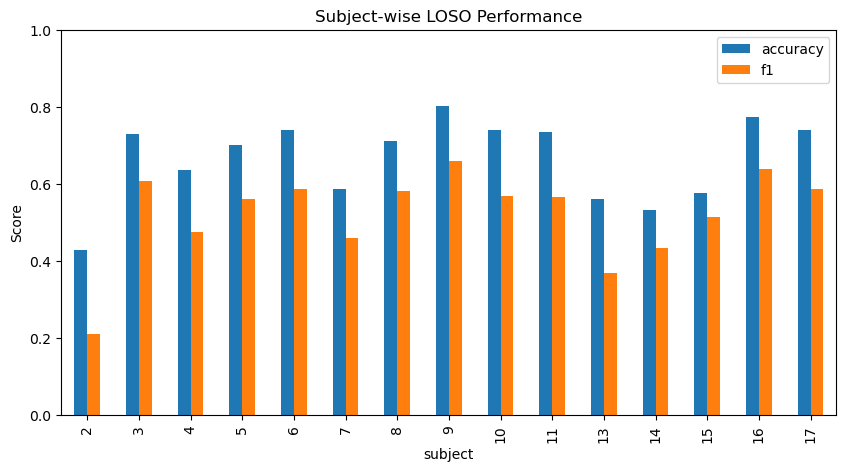

In [13]:
metrics_df.plot(x="subject", y=["accuracy","f1"], kind="bar", figsize=(10,5))
plt.title("Subject-wise LOSO Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

The Random Forest model achieves moderate accuracy and F1 scores across subjects, with overall accuracies ranging from 0.43 to 0.80. Some subjects (e.g., 9, 16, 17) are predicted well, while others (e.g., 2) have lower performance, likely due to atypical signal patterns or class imbalance.  

This highlights the challenge of inter-subject variability in biosignal data and suggests that future improvements could include more robust features, advanced models like CNNs, or data augmentation to handle minority labels.


In [9]:
metrics_df = pd.DataFrame(all_metrics)

print("\nLOSO Summary:")
print(metrics_df[["accuracy", "f1"]].describe())


LOSO Summary:
        accuracy         f1
count  15.000000  15.000000
mean    0.666310   0.521227
std     0.106925   0.116903
min     0.427336   0.210979
25%     0.581911   0.467009
50%     0.712146   0.565833
75%     0.740320   0.587241
max     0.801336   0.660347


## Global Confusion Matrix

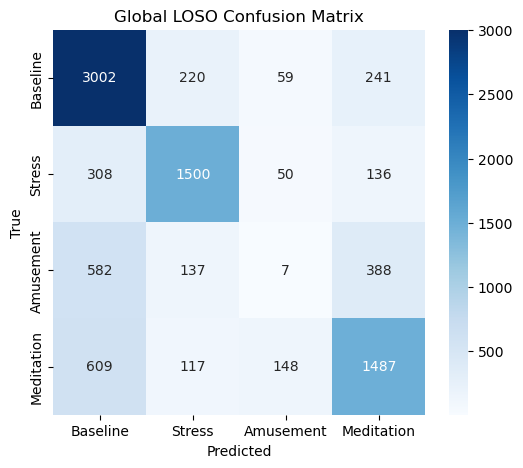

In [10]:
cm_global = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_global,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES[1:],
    yticklabels=LABEL_NAMES[1:]
)
plt.title("Global LOSO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The global confusion matrix reveals that the model struggles with the Amusement class, correctly predicting only 7 windows across all subjects. This likely reflects class imbalance and overlapping signals, makeign this class difficult to distinguish using the current Random Forest with summary statistic features.

## Class-wise F1 Scores

In [11]:
# Class-wise F1 scores
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=LABEL_NAMES[1:]
))

              precision    recall  f1-score   support

    Baseline       0.67      0.85      0.75      3522
      Stress       0.76      0.75      0.76      1994
   Amusement       0.03      0.01      0.01      1114
  Meditation       0.66      0.63      0.64      2361

    accuracy                           0.67      8991
   macro avg       0.53      0.56      0.54      8991
weighted avg       0.61      0.67      0.63      8991



It seems clear the model struggles with less-common states like Amusement or Meditation compared to commons tates like Baseline aand Stress. This shows the challenges of inter-subject variability and minority class prediction in biosignal data. Future improvements could include richer features, data augmentation, or deep learning models like CNNs to better capture temporal patterns.